# Bree ML Take-Home: Loan Default Prediction Model

In this notebook, we are going to build an interpretable prediction model to predict loan defaults using a synthetic dataset

## Initial EDA and Addressing Data Issues 

We will start by loading the generated dataset and looking at its basic structure. 

The goal of this section is to understand what fields we can use, where the missing values are, how the outcomes are distributed, and what issues we need to explicitly handle before modelling. 

In [31]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

DATA_PATH = Path("../data/loan_applications.csv")

df = pd.read_csv(DATA_PATH)
print(df.shape)

(2000, 15)


In [32]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nFirst 5 rows:")
display(df.head())

Shape: (2000, 15)

Columns:
['applicant_id', 'stated_monthly_income', 'documented_monthly_income', 'loan_amount', 'employment_status', 'bank_ending_balance', 'bank_has_overdrafts', 'bank_has_consistent_deposits', 'monthly_withdrawals', 'monthly_deposits', 'num_documents_submitted', 'rule_based_score', 'rule_based_decision', 'actual_outcome', 'days_to_default']

Data types:


,dtype
applicant_id,str
stated_monthly_income,float64
documented_monthly_income,float64
loan_amount,int64
employment_status,str
bank_ending_balance,float64
bank_has_overdrafts,bool
bank_has_consistent_deposits,bool
monthly_withdrawals,float64
monthly_deposits,float64



First 5 rows:


,applicant_id,stated_monthly_income,documented_monthly_income,loan_amount,employment_status,bank_ending_balance,bank_has_overdrafts,bank_has_consistent_deposits,monthly_withdrawals,monthly_deposits,num_documents_submitted,rule_based_score,rule_based_decision,actual_outcome,days_to_default
0,APP-0000,3683.0,3462.0,2000,employed,3084.0,False,True,1927.0,3337.0,1,67.7,flagged_for_review,repaid,NaN
1,APP-0001,2011.0,1880.0,1500,unemployed,1525.0,False,True,776.0,1844.0,2,57.3,flagged_for_review,repaid,NaN
2,APP-0002,820.0,201.0,1500,self_employed,4091.0,False,True,145.0,180.0,2,30.9,denied,repaid,NaN
3,APP-0003,5551.0,5264.0,3000,employed,772.0,False,True,1747.0,4549.0,1,69.7,flagged_for_review,ongoing,NaN
4,APP-0004,6370.0,5880.0,2000,employed,2254.0,False,True,4673.0,5222.0,2,87.1,approved,repaid,NaN


Before defining our target, let's look at some of the key data issues discussed in the project assignment. 

In particular, we will look at missing documented income, the class balance in the outcome column, and the main categorical fields such as employment status and the current rule-based decision.

In [33]:
missing_summary = (
    df.isna().sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(df)).round(4)

display(missing_summary)

for col in ["actual_outcome", "employment_status", "rule_based_decision"]:
    print(f"\nValue counts for {col}:")
    display(df[col].value_counts(dropna=False).to_frame("count"))
    display((df[col].value_counts(dropna=False, normalize=True) * 100).round(2).to_frame("pct"))

,missing_count,missing_pct
days_to_default,1455,0.7275
documented_monthly_income,283,0.1415
applicant_id,0,0.0000
loan_amount,0,0.0000
employment_status,0,0.0000
bank_ending_balance,0,0.0000
stated_monthly_income,0,0.0000
bank_has_overdrafts,0,0.0000
bank_has_consistent_deposits,0,0.0000
monthly_deposits,0,0.0000



Value counts for actual_outcome:


,count
actual_outcome,
repaid,1291
defaulted,545
ongoing,164


,pct
actual_outcome,
repaid,64.55
defaulted,27.25
ongoing,8.20



Value counts for employment_status:


,count
employment_status,
employed,1183
self_employed,620
unemployed,197


,pct
employment_status,
employed,59.15
self_employed,31.00
unemployed,9.85



Value counts for rule_based_decision:


,count
rule_based_decision,
approved,922
flagged_for_review,800
denied,278


,pct
rule_based_decision,
approved,46.1
flagged_for_review,40.0
denied,13.9


To predict the risk of defaulting, we will be doing supervised learning which means our outcomes must be known. 

Therefore I am making the decision to exclude the `ongoing` applications from training because their true outcome it not observed yet. 

This will introduce bias as some of the ongoing loans may eventually default, so removing them may make the training sample cleaner than the true sample, once those loans are completed. 



In [34]:
resolved_df = df[df["actual_outcome"].isin(["repaid", "defaulted"])].copy()
resolved_df["target_default"] = (resolved_df["actual_outcome"] == "defaulted").astype(int)

print("Full dataset shape:", df.shape)
print("Resolved dataset shape:", resolved_df.shape)

print("\nResolved target counts:")
display(resolved_df["target_default"].value_counts().to_frame("count"))

print("\nResolved target percentages:")
display((resolved_df["target_default"].value_counts(normalize=True) * 100).round(2).to_frame("pct"))

Full dataset shape: (2000, 15)
Resolved dataset shape: (1836, 16)

Resolved target counts:


,count
target_default,
0,1291
1,545



Resolved target percentages:


,pct
target_default,
0,70.32
1,29.68


Firstly, we plot the overall outcome distribution. This gives a quick read on the class imbalance and also shows how many applications are still ongoing, which matters for how we define the training set.

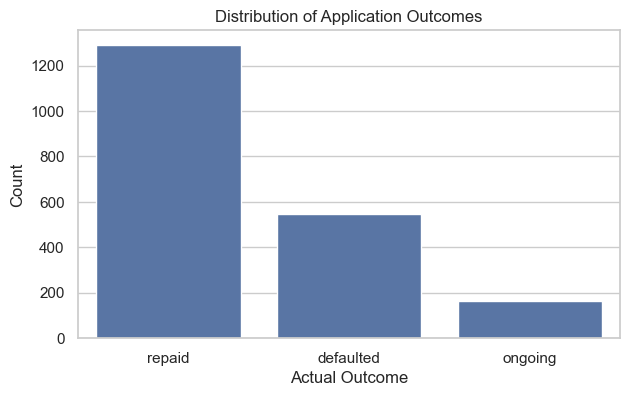

In [35]:
outcome_counts = df["actual_outcome"].value_counts()

plt.figure(figsize=(7, 4))
sns.barplot(x=outcome_counts.index, y=outcome_counts.values)
plt.title("Distribution of Application Outcomes")
plt.xlabel("Actual Outcome")
plt.ylabel("Count")
plt.show()

The assignment explicitly mentions that a non-trivial amount of `documented_monthly_income` values are missing because some applicants did not submit documents. 

This absence may not be random, so rather than removing these rows, we will check whether the presence or absence of documented income appears related to outcomes, because that would make it a potentially useful feature rather than just a null to impute away.

,actual_outcome,share_with_documented_income
0,defaulted,0.766972
1,ongoing,0.847561
2,repaid,0.898528


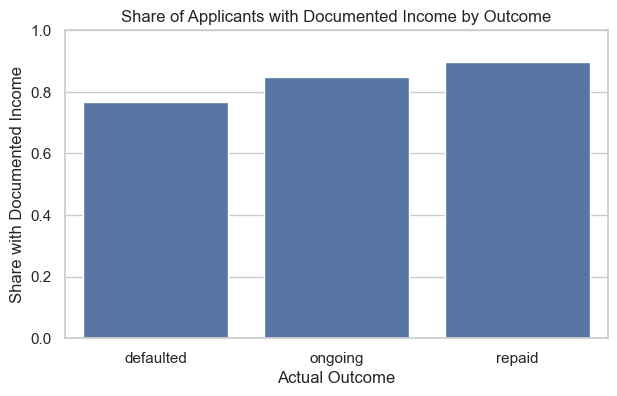

In [36]:
df["has_documented_income"] = df["documented_monthly_income"].notna()

doc_rate_by_outcome = (
    df.groupby("actual_outcome")["has_documented_income"]
      .mean()
      .reset_index(name="share_with_documented_income")
)

display(doc_rate_by_outcome)

plt.figure(figsize=(7, 4))
sns.barplot(
    data=doc_rate_by_outcome,
    x="actual_outcome",
    y="share_with_documented_income"
)
plt.title("Share of Applicants with Documented Income by Outcome")
plt.xlabel("Actual Outcome")
plt.ylabel("Share with Documented Income")
plt.ylim(0, 1)
plt.show()

Before modelling, we will also engineer a few features that map cleanly to the business problem given in the assignment. Looking at the data generation code, we can already see some risk patterns being described, for example: income documentation, possible income misrepresentation, loan burden, and cash flow strain. We will generate features for exactly these values. 

Also we are deliberately not using `days_to_default` as a feature because it is only observed after a default occurs, and we are also not using the rule-based outputs as model inputs because those should be treated as the baseline for comparison rather than information our model is allowed to rely on.

In [37]:
resolved_df["has_documented_income"] = resolved_df["documented_monthly_income"].notna().astype(int)

resolved_df["stated_to_documented_ratio"] = (
    resolved_df["stated_monthly_income"] / resolved_df["documented_monthly_income"]
)

resolved_df["income_gap_pct"] = (
    (resolved_df["stated_monthly_income"] - resolved_df["documented_monthly_income"])
    / resolved_df["documented_monthly_income"]
)

resolved_df["suspected_misrepresentation"] = (
    resolved_df["stated_to_documented_ratio"] >= 3
).fillna(False).astype(int)

resolved_df["loan_to_stated_income"] = (
    resolved_df["loan_amount"] / resolved_df["stated_monthly_income"]
)

resolved_df["loan_to_documented_income"] = (
    resolved_df["loan_amount"] / resolved_df["documented_monthly_income"]
)

resolved_df["withdrawal_deposit_ratio"] = (
    resolved_df["monthly_withdrawals"] / resolved_df["monthly_deposits"]
)

resolved_df["net_monthly_cashflow"] = (
    resolved_df["monthly_deposits"] - resolved_df["monthly_withdrawals"]
)

engineered_cols = [
    "has_documented_income",
    "stated_to_documented_ratio",
    "income_gap_pct",
    "suspected_misrepresentation",
    "loan_to_stated_income",
    "loan_to_documented_income",
    "withdrawal_deposit_ratio",
    "net_monthly_cashflow",
]

display(resolved_df[engineered_cols].head())

,has_documented_income,stated_to_documented_ratio,income_gap_pct,suspected_misrepresentation,loan_to_stated_income,loan_to_documented_income,withdrawal_deposit_ratio,net_monthly_cashflow
0,1,1.063836,0.063836,0,0.543036,0.577701,0.577465,1410.0
1,1,1.069681,0.069681,0,0.745898,0.797872,0.420824,1068.0
2,1,4.079602,3.079602,1,1.829268,7.462687,0.805556,35.0
4,1,1.083333,0.083333,0,0.313972,0.340136,0.894868,549.0
5,1,1.033215,0.033215,0,0.527009,0.544514,0.681761,1012.0


Now that these features exist, we will do a quick sanity check on whether they actually separate good and bad outcomes in a sensible way. We want to see whether the model will have usable signal from intuitive business features.

In [38]:
feature_snapshot = (
    resolved_df.groupby("target_default")[[
        "has_documented_income",
        "suspected_misrepresentation",
        "loan_to_stated_income",
        "withdrawal_deposit_ratio",
        "net_monthly_cashflow",
        "bank_ending_balance",
        "bank_has_overdrafts"
    ]]
    .mean()
    .T
)

feature_snapshot.columns = ["repaid_mean", "defaulted_mean"]
display(feature_snapshot)

,repaid_mean,defaulted_mean
has_documented_income,0.898528,0.766972
suspected_misrepresentation,0.023238,0.040367
loan_to_stated_income,0.434068,0.683165
withdrawal_deposit_ratio,0.606391,0.638014
net_monthly_cashflow,1600.130906,1274.955963
bank_ending_balance,2209.168861,1887.493578
bank_has_overdrafts,0.119287,0.266055


One intuitive risk indicator is the burden of the loan: if the requested loan amount is large relative to income, repayment should be harder. Let's visualize that relationship on the resolved subset to see whether the defaulted applicants appear more stretched on this measure.

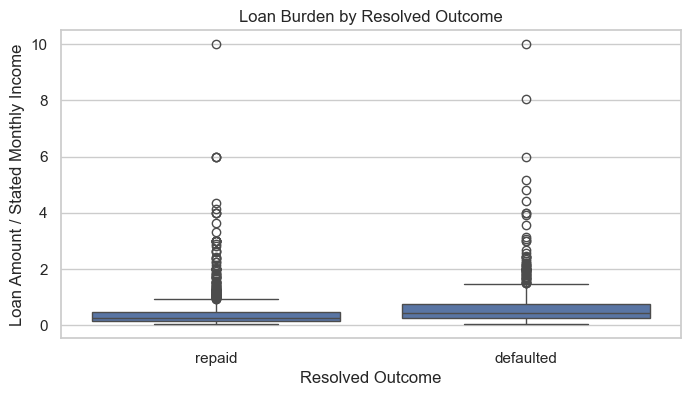

In [39]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=resolved_df,
    x="actual_outcome",
    y="loan_to_stated_income"
)
plt.title("Loan Burden by Resolved Outcome")
plt.xlabel("Resolved Outcome")
plt.ylabel("Loan Amount / Stated Monthly Income")
plt.show()

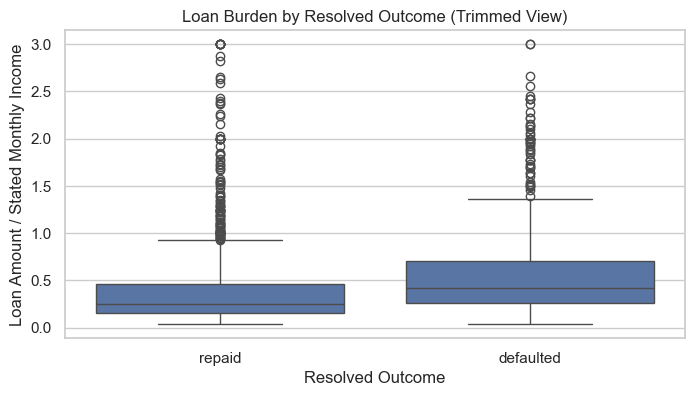

In [40]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=resolved_df[resolved_df["loan_to_stated_income"] <= 3],
    x="actual_outcome",
    y="loan_to_stated_income"
)
plt.title("Loan Burden by Resolved Outcome (Trimmed View)")
plt.xlabel("Resolved Outcome")
plt.ylabel("Loan Amount / Stated Monthly Income")
plt.show()

Let's also inspect the distribution of the cash flow feature. The rule-based system uses a debt-to-income style ratio based on withdrawals and deposits, so plotting the withdrawal-to-deposit ratio is a useful check for whether that signal is meaningfully related to defaulting.

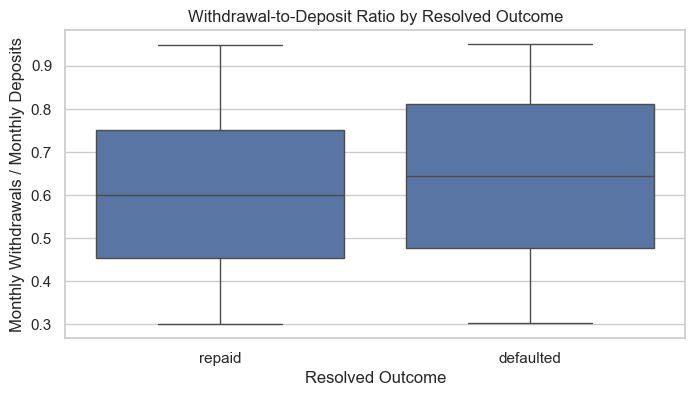

In [41]:
plt.figure(figsize=(8, 4))
sns.boxplot(
    data=resolved_df,
    x="actual_outcome",
    y="withdrawal_deposit_ratio"
)
plt.title("Withdrawal-to-Deposit Ratio by Resolved Outcome")
plt.xlabel("Resolved Outcome")
plt.ylabel("Monthly Withdrawals / Monthly Deposits")
plt.show()

Before moving into modeling, let's look at two simple cross-tabs. The first shows how outcomes vary by employment status, which will be useful later for the fairness discussion. The second shows how the current rule-based system’s decisions relate to actual outcomes, which gives an early baseline sanity check before formal evaluation.

In [42]:
display(
    pd.crosstab(
        df["employment_status"],
        df["actual_outcome"],
        normalize="index"
    ).round(3)
)

display(
    pd.crosstab(
        df["rule_based_decision"],
        df["actual_outcome"],
        normalize="index"
    ).round(3)
)

actual_outcome,defaulted,ongoing,repaid
employment_status,,,
employed,0.250,0.080,0.669
self_employed,0.265,0.087,0.648
unemployed,0.431,0.076,0.492


actual_outcome,defaulted,ongoing,repaid
rule_based_decision,,,
approved,0.153,0.077,0.770
denied,0.514,0.047,0.439
flagged_for_review,0.326,0.100,0.574


At this point, we have a clear view of the main data issues, a target definition, and an initial sense of how both employment groups and the existing rule-based system relate to realized outcomes. With that context in place, we can move into model choice and train an interpretable model.

## Model Choice 

We have a specific target definition and a first set of engineered risk features. The next step is to choose a model that will learn useful signals while still being interpretable enough so that we know why its making its decisions. 

For this task, we will use logistic regression. I believe it is a good fit because: the data is binary (now that we've removed the `ongoing` values), the dataset is relatively small, and the biggest reason being that the model's decisions will be very interpretable as we will have specific weights for the coefficients of each feature. 

We will begin with a relatively compact feature set, rather than throwing every possible correlated variable into the model. 

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

We are deliberately excluding a few columns: 

- `days_to_default` since it is only known after default happens and leaks the outcome
- `rule_based_score` and `rule_based_decision`, because those belong to the current baseline system and should not be used as inputs to the new model
- some highly redundant engineered variables, to keep the logistic regression coefficients more stable and easier to interpret

We begin with a set of features, including the ones we previously engineered. 

In [44]:
numeric_features = [
    "loan_amount",
    "bank_ending_balance",
    "net_monthly_cashflow",
    "num_documents_submitted",
    "has_documented_income",
    "suspected_misrepresentation",
    "bank_has_overdrafts",
    "bank_has_consistent_deposits",
]

categorical_features = [
    "employment_status"
]

selected_features = numeric_features + categorical_features

X = resolved_df[selected_features].copy()
y = resolved_df["target_default"].copy()

print("Selected features:")
print(selected_features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

Selected features:
['loan_amount', 'bank_ending_balance', 'net_monthly_cashflow', 'num_documents_submitted', 'has_documented_income', 'suspected_misrepresentation', 'bank_has_overdrafts', 'bank_has_consistent_deposits', 'employment_status']

X shape: (1836, 9)
y shape: (1836,)


Since the target is somewhat imbalanced, we make sure our train/test split keeps the same class proportion in either group. We will use pipelines so that imputation, encoding, and scaling are learned on the training set only. 

For the numeric features, we will be using median imputation and standardization. For the employment status we will be one-hot encoding. We will also be using `class_weight="balanced"` in logistic regression so the minority default class is not underweighted during training.

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        ),
    ]
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1377, 9)
Test shape: (459, 9)


We can now fit the model

In [47]:
log_reg_pipeline.fit(X_train, y_train)

test_pred_proba = log_reg_pipeline.predict_proba(X_test)[:, 1]

initial_auc = roc_auc_score(y_test, test_pred_proba)
print(f"Initial holdout ROC AUC: {initial_auc:.3f}")

Initial holdout ROC AUC: 0.726


The advantage of using logistic regression is that we can inspect the learned coefficients directly. Since the numeric variables were standardized before training, the coefficient magnitudes are more comparable across numeric features.

Positive coefficients indicate that higher values of the feature push predicted default risk upward, while negative coefficients indicate the opposite.

In [48]:
feature_names = log_reg_pipeline.named_steps["preprocess"].get_feature_names_out()
coefficients = log_reg_pipeline.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients,
    "odds_ratio": np.exp(coefficients)
})

coef_df["feature"] = (
    coef_df["feature"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
)

coef_df = coef_df.sort_values("coefficient", ascending=False).reset_index(drop=True)

display(coef_df)

,feature,coefficient,odds_ratio
0,loan_amount,0.475792,1.609289
1,employment_status_unemployed,0.473501,1.605606
2,bank_has_overdrafts,0.397172,1.487612
3,num_documents_submitted,0.239106,1.270113
4,suspected_misrepresentation,0.152424,1.164654
5,employment_status_self_employed,0.116726,1.123812
6,bank_has_consistent_deposits,0.059606,1.061418
7,bank_ending_balance,-0.056905,0.944684
8,net_monthly_cashflow,-0.335337,0.715097
9,has_documented_income,-0.609131,0.543823


We also visualize the strongest positive and negative drivers of our predictions

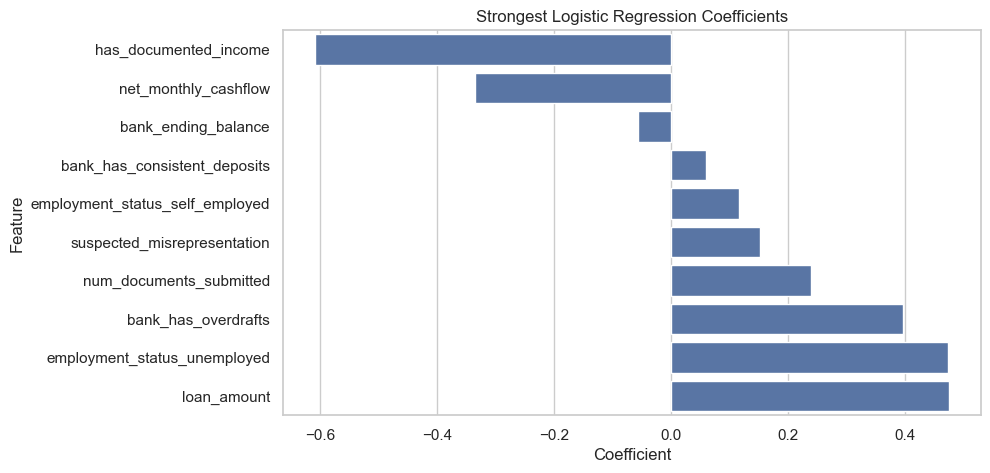

In [49]:
top_positive = coef_df.head(5)
top_negative = coef_df.tail(5)

coef_plot_df = pd.concat([top_positive, top_negative]).sort_values("coefficient")

plt.figure(figsize=(9, 5))
sns.barplot(
    data=coef_plot_df,
    x="coefficient",
    y="feature"
)
plt.title("Strongest Logistic Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

Now that we have our model, we can begin to evaluate it more formally and compare it with the current rule-based system. 

## Evalutaion + Comparison

Now that our logistic regression model is trained, we will compare it directly against the current rule-based system on the same resolved holdout set.

There are really two different comparisons to make here:

1. **ranking quality**, which we measure with ROC AUC using each system’s score
2. **actual decision behavior**, which we measure with precision, recall, F1, and confusion matrices using each system’s thresholded predictions

For the logistic regression model, we will use the predicted default probability as the score and a threshold of 0.5 for the binary prediction. For the rule-based system, we will use `rule_based_score` as the score and convert the rule-based decision into a binary risk prediction.

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

To make the comparison fair, both systems need to be mapped onto the same binary task: predicting whether an application will default.

For the rule-based system, I will treat:
- `approved` as predicted non-default
- `flagged_for_review` and `denied` as predicted default

This is not a perfect one-to-one match, since "flagged for review" is not the same thing as denial, but it is a reasonable way to convert the existing system into a binary comparator for default-risk screening.

In [56]:
eval_df = resolved_df.loc[y_test.index].copy()

eval_df["model_score"] = test_pred_proba
eval_df["model_pred"] = (eval_df["model_score"] >= 0.5).astype(int)

eval_df["baseline_score"] = 100 - eval_df["rule_based_score"]
eval_df["baseline_pred"] = eval_df["rule_based_decision"].isin(
    ["flagged_for_review", "denied"]
).astype(int)

display(eval_df[[
    "actual_outcome",
    "target_default",
    "model_score",
    "model_pred",
    "rule_based_score",
    "rule_based_decision",
    "baseline_pred"
]].head())

,actual_outcome,target_default,model_score,model_pred,rule_based_score,rule_based_decision,baseline_pred
1849,repaid,0,0.708207,1,53.4,flagged_for_review,1
768,repaid,0,0.555162,1,62.0,flagged_for_review,1
871,repaid,0,0.212737,0,84.1,approved,0
311,defaulted,1,0.713023,1,34.7,denied,1
350,repaid,0,0.313697,0,82.7,approved,0


Before looking at confusion matrices, we write a compact metric summary for both systems. This will show whether the model is better at ranking risk, whether it catches more defaulters, and whether it does so at the cost of flagging too many borrowers who would have repaid.

In [57]:
def compute_metrics(y_true, y_pred, y_score):
    return pd.Series({
        "roc_auc": roc_auc_score(y_true, y_score),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "positive_prediction_rate": np.mean(y_pred)
    })

metrics_df = pd.DataFrame({
    "logistic_regression": compute_metrics(
        y_test,
        eval_df["model_pred"],
        eval_df["model_score"]
    ),
    "rule_based_system": compute_metrics(
        y_test,
        eval_df["baseline_pred"],
        eval_df["baseline_score"]
    )
}).T.round(3)

display(metrics_df)

,roc_auc,precision,recall,f1,accuracy,positive_prediction_rate
logistic_regression,0.726,0.459,0.654,0.539,0.669,0.423
rule_based_system,0.725,0.409,0.765,0.533,0.603,0.553


These summary metrics are useful, but they do not fully show the risk. In this setting:

- a **false negative** means a likely defaulter was missed 
- a **false positive** means a borrower who would have repaid was unnecessarily blocked or flagged

The confusion matrices make that tradeoff much easier to see.

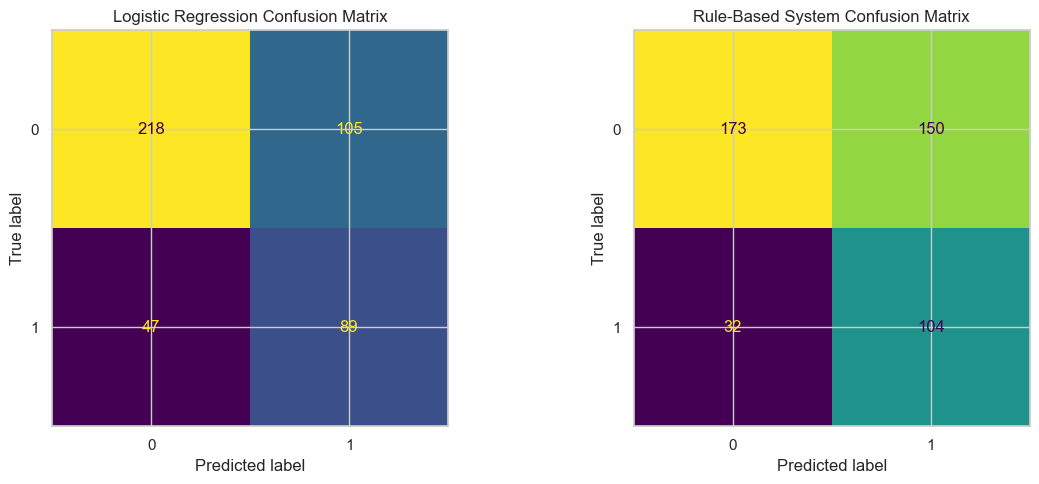

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    eval_df["model_pred"],
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Logistic Regression Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    eval_df["baseline_pred"],
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Rule-Based System Confusion Matrix")

plt.tight_layout()
plt.show()

We also calculate the proportions of false positive and false negative rates. Therefore we can make further business and operational conclusions

In [59]:
def error_breakdown(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return pd.Series({
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "false_positive_rate": fp / (fp + tn),
        "false_negative_rate": fn / (fn + tp)
    })

error_df = pd.DataFrame({
    "logistic_regression": error_breakdown(y_test, eval_df["model_pred"]),
    "rule_based_system": error_breakdown(y_test, eval_df["baseline_pred"])
}).T.round(3)

display(error_df)

,TN,FP,FN,TP,false_positive_rate,false_negative_rate
logistic_regression,218.0,105.0,47.0,89.0,0.325,0.346
rule_based_system,173.0,150.0,32.0,104.0,0.464,0.235


## Fairness Analysis

We want to analyze the fairness in how we treat the `employement_status` feature because the current rule-based system penalizes self-employed applicants. 

To assess this, we will check whether the observed default rates actually differ meaningfully across employment groups, and then compare how our logistic regression model and the rule based system behave for each group. 



In [60]:
fairness_base = (
    resolved_df.groupby("employment_status")
    .agg(
        n_applications=("target_default", "size"),
        default_rate=("target_default", "mean")
    )
    .sort_values("n_applications", ascending=False)
)

fairness_base["default_rate"] = fairness_base["default_rate"].round(3)
display(fairness_base)

,n_applications,default_rate
employment_status,,
employed,1088,0.272
self_employed,566,0.290
unemployed,182,0.467


We'll also visualize this observed default rate by employment group. 

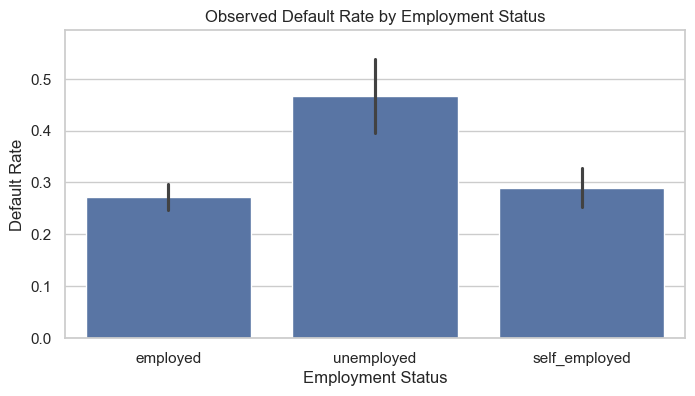

In [61]:
plt.figure(figsize=(8, 4))
sns.barplot(
    data=resolved_df,
    x="employment_status",
    y="target_default",
    estimator="mean"
)
plt.title("Observed Default Rate by Employment Status")
plt.xlabel("Employment Status")
plt.ylabel("Default Rate")
plt.ylim(0, resolved_df["target_default"].mean() * 2)
plt.show()

Next, we will compare how often our two systems deny or flag applicants within each employment group. 

This comparison will demonstrate if a group is screened more aggressively even if their default rates are not meaningfully higher. 

In [63]:
group_decision_summary = (
    eval_df.groupby("employment_status")
    .agg(
        n_holdout=("target_default", "size"),
        actual_default_rate=("target_default", "mean"),
        model_risky_rate=("model_pred", "mean"),
        baseline_risky_rate=("baseline_pred", "mean")
    )
    .sort_values("n_holdout", ascending=False)
    .round(3)
)

display(group_decision_summary)

,n_holdout,actual_default_rate,model_risky_rate,baseline_risky_rate
employment_status,,,,
employed,271,0.258,0.380,0.435
self_employed,140,0.271,0.429,0.629
unemployed,48,0.583,0.646,1.000


Additionally we visualize this comparison. 

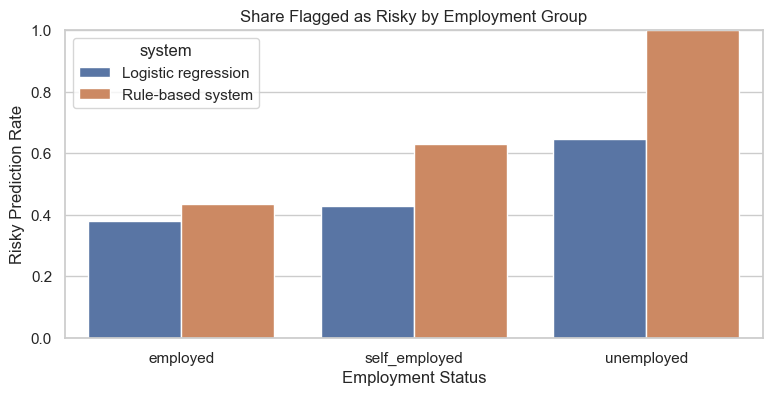

In [65]:
decision_plot_df = (
    group_decision_summary[["model_risky_rate", "baseline_risky_rate"]]
    .reset_index()
    .melt(
        id_vars="employment_status",
        var_name="system",
        value_name="risky_rate"
    )
)

decision_plot_df["system"] = decision_plot_df["system"].replace({
    "model_risky_rate": "Logistic regression",
    "baseline_risky_rate": "Rule-based system"
})

plt.figure(figsize=(9, 4))
sns.barplot(
    data=decision_plot_df,
    x="employment_status",
    y="risky_rate",
    hue="system"
)
plt.title("Share Flagged as Risky by Employment Group")
plt.xlabel("Employment Status")
plt.ylabel("Risky Prediction Rate")
plt.ylim(0, 1)
plt.show()

To account for one employment group actually having a higher default risk, we compare false positive rates. 

In this case a false positive is an applicant who was labelled risky, but would have repaid. 

In [66]:
def group_false_positive_rate(df_group, pred_col):
    repaid_only = df_group[df_group["target_default"] == 0]
    if len(repaid_only) == 0:
        return np.nan
    return (repaid_only[pred_col] == 1).mean()

group_fpr = pd.DataFrame({
    "model_fpr": eval_df.groupby("employment_status").apply(
        lambda x: group_false_positive_rate(x, "model_pred")
    ),
    "baseline_fpr": eval_df.groupby("employment_status").apply(
        lambda x: group_false_positive_rate(x, "baseline_pred")
    )
}).round(3)

display(group_fpr)

,model_fpr,baseline_fpr
employment_status,,
employed,0.303,0.368
self_employed,0.353,0.549
unemployed,0.400,1.000


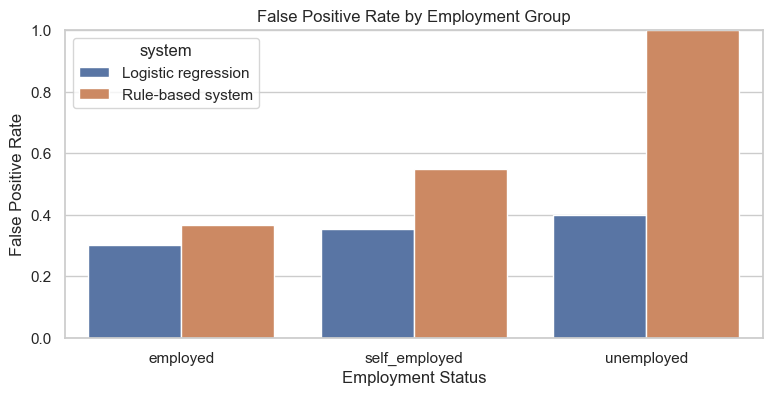

In [67]:
group_fpr_plot_df = (
    group_fpr.reset_index()
    .melt(
        id_vars="employment_status",
        var_name="system",
        value_name="false_positive_rate"
    )
)

group_fpr_plot_df["system"] = group_fpr_plot_df["system"].replace({
    "model_fpr": "Logistic regression",
    "baseline_fpr": "Rule-based system"
})

plt.figure(figsize=(9, 4))
sns.barplot(
    data=group_fpr_plot_df,
    x="employment_status",
    y="false_positive_rate",
    hue="system"
)
plt.title("False Positive Rate by Employment Group")
plt.xlabel("Employment Status")
plt.ylabel("False Positive Rate")
plt.ylim(0, 1)
plt.show()